# Predict future Bitcoin prices using ML models

In [ ]:
!pip install yfinance streamlit

In [ ]:
!pip install tensorflow 

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

### Get Data

In [11]:
import yfinance as yf

df = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")
df.to_csv("data/crypto.csv")

[*********************100%***********************]  1 of 1 completed


In [10]:
#save files:
os.makedirs("outputs/graphs", exist_ok=True)
os.makedirs("models", exist_ok=True)

## Data Pre-Process

In [16]:
df = df[['Close']]
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index)

## EDA

In [18]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Bitcoin Price')
plt.title("Bitcoin Price Trend")
plt.legend()
plt.savefig("outputs/graphs/price_trend.png")
plt.close()

## Feature Engineering

In [19]:
df['Prediction'] = df['Close'].shift(-30)

## Train-Test Split

In [21]:
X = np.array(df[['Close']])[:-30]
y = np.array(df['Prediction'])[:-30]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Linear Regression

In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

## LSTM

In [24]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    Input(shape=(X_lstm.shape[1], 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_lstm, y_lstm, epochs=5, batch_size=32, verbose=0)

model.save("models/lstm_model.keras")

## LSTM Prediction

In [25]:
lstm_pred = model.predict(X_lstm[-len(X_test):])
lstm_pred = scaler.inverse_transform(lstm_pred)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


## Evaluation using RMSE

In [26]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))

print("Linear Regression RMSE:", lr_rmse)
print("LSTM RMSE:", lstm_rmse)

Linear Regression RMSE: 6365.063087483909
LSTM RMSE: 15782.909951966682


## Visualization

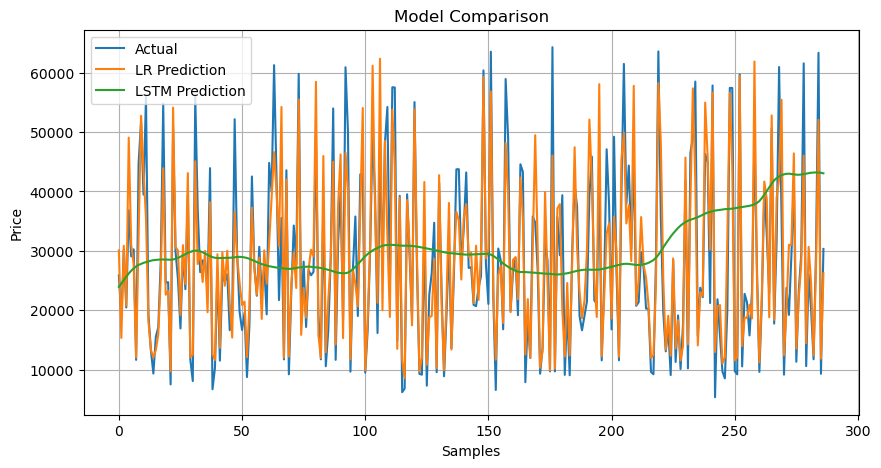

In [30]:
plt.figure(figsize=(10,5))

plt.plot(y_test, label='Actual')
plt.plot(lr_pred, label='LR Prediction')
plt.plot(lstm_pred, label='LSTM Prediction')

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.grid(True)

# Save graph
plt.savefig("outputs/graphs/final_comparison.png")

# SHOW graph in output
plt.show()

In [31]:
#The plot shows that while Linear Regression predictions fluctuate heavily and fail to match the actual price pattern, 
#the LSTM model produces smoother predictions that better follow the overall trend of Bitcoin prices.